# Task 4 — Fine-Tuning a Transformer for Sentiment Classification
### Yelp Review Full (binary sentiment) — DistilBERT

A lean, no-frills version: load data, tokenise, fine-tune DistilBERT, evaluate, compare
against the Task 2 classical baseline, and discuss practical implications. Same binary
sentiment mapping as Tasks 1–3: 1-2 stars → negative, 4-5 stars → positive, 3 stars dropped.

Runs on Colab (T4 GPU recommended: Runtime > Change runtime type > T4 GPU). CPU works but
is much slower.

## 0. Setup

In [1]:
!pip install -q transformers datasets accelerate scikit-learn pandas matplotlib

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments, set_seed,
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

SEED = 42
set_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


# **4.1 Load data and create a small labelled subset**

The brief recommends ~1,000-5,000 labelled examples for fine-tuning, so unlike the classical
baseline (which used tens of thousands of examples), we deliberately keep this small.

In [3]:
dataset = load_dataset("Yelp/yelp_review_full")

def to_binary(example):
    star = example["label"] + 1
    example["sentiment"] = 0 if star <= 2 else (1 if star >= 4 else -1)
    return example

dataset = dataset.map(to_binary)
dataset = dataset.filter(lambda ex: ex["sentiment"] != -1)
dataset = dataset.rename_column("sentiment", "label_bin")

README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  299MB            

yelp_review_full/train-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

yelp_review_full/test-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 23.5MB            

yelp_review_full/test-00000-of-00001.par(…): downloading bytes:           |  0.00B            

...

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/650000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/650000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [17]:
# Stratified-ish split: shuffle then slice (dataset is large enough that class balance
# stays close to 50/50 without needing an explicit stratified split).
TRAIN_N, VAL_N, TEST_N = 4000, 500, 500

pool = dataset["train"].shuffle(seed=SEED).select(range(TRAIN_N + VAL_N))
train_ds = pool.select(range(TRAIN_N))
val_ds = pool.select(range(TRAIN_N, TRAIN_N + VAL_N))
test_ds = dataset["test"].shuffle(seed=SEED).select(range(TEST_N))

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print("Train class balance:", pd.Series(train_ds["label_bin"]).value_counts().to_dict())

Train: 4000 | Val: 500 | Test: 500
Train class balance: {1: 2037, 0: 1963}


In [5]:
train_ds = train_ds.remove_columns(["label"])
val_ds = val_ds.remove_columns(["label"])
test_ds = test_ds.remove_columns(["label"])

## 2. Tokenisation

DistilBERT needs almost no manual preprocessing — no stopword removal, no lemmatisation.
Unlike Task 2's classical pipeline, subword tokenisation handles vocabulary directly, and
aggressive cleaning would only throw away context (capitalisation, punctuation) the model
can otherwise use.

In [6]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

tokenized_train = train_ds.map(tokenize_batch, batched=True)
tokenized_val = val_ds.map(tokenize_batch, batched=True)
tokenized_test = test_ds.map(tokenize_batch, batched=True)

tokenized_train = tokenized_train.rename_column("label_bin", "labels")
tokenized_val = tokenized_val.rename_column("label_bin", "labels")
tokenized_test = tokenized_test.rename_column("label_bin", "labels")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

## 3. Load the model

In [7]:
id2label = {0: "negative", 1: "positive"}
label2id = {"negative": 0, "positive": 1}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, id2label=id2label, label2id=label2id
).to(DEVICE)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters: 66,955,010


## 4. Training configuration and metrics

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    macro_f1 = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)[2]
    weighted_f1 = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)[2]
    return {"accuracy": acc, "precision": precision, "recall": recall,
            "f1": f1, "macro_f1": macro_f1, "weighted_f1": weighted_f1}

In [9]:
training_args = TrainingArguments(
    output_dir="distilbert_yelp",
    learning_rate=2e-5,
    per_device_train_batch_size=16,   # drop to 8 if you hit a Colab GPU out-of-memory error
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=torch.cuda.is_available(),
    logging_steps=25,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,   # was: tokenizer=tokenizer
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

## 5. Fine-tune

Fallback: if this runs out of memory or time on your Colab tier, drop `TRAIN_N` to ~1,000-2,000
and/or `per_device_train_batch_size` to 8, and note that fallback explicitly in your report,
comparing the smaller run's numbers against the Task 2 baseline rather than skipping the
comparison.

In [10]:
start = time.time()
trainer.train()
training_minutes = (time.time() - start) / 60
print(f"Training time: {training_minutes:.2f} minutes")
print(f"Best validation metric: {trainer.state.best_metric:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1,Weighted F1
1,0.267415,0.197855,0.912000,0.883534,0.936170,0.909091,0.911910,0.912079
2,0.137529,0.230085,0.918000,0.918103,0.906383,0.912206,0.917641,0.917967


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training time: 0.94 minutes
Best validation metric: 0.9122


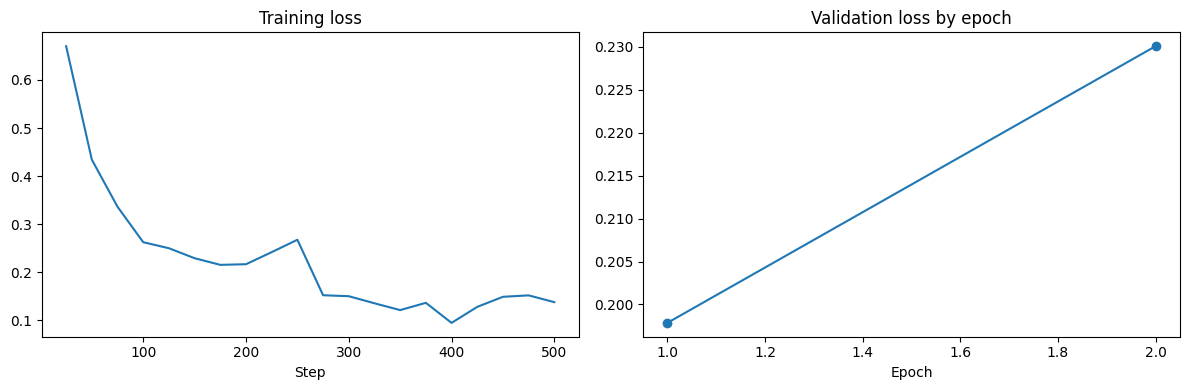

In [11]:
# Quick look at training/validation loss over time
history = pd.DataFrame(trainer.state.log_history)
train_logs = history[history["loss"].notna()] if "loss" in history.columns else pd.DataFrame()
eval_logs = history[history.get("eval_loss").notna()] if "eval_loss" in history.columns else pd.DataFrame()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if not train_logs.empty:
    axes[0].plot(train_logs["step"], train_logs["loss"])
    axes[0].set_title("Training loss")
    axes[0].set_xlabel("Step")
if not eval_logs.empty:
    axes[1].plot(eval_logs["epoch"], eval_logs["eval_loss"], marker="o", label="val loss")
    axes[1].set_title("Validation loss by epoch")
    axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.savefig("task4_training_curves.png", dpi=150)
plt.show()

## 6. Final evaluation on the held-out test set

Uses the same metric set the brief asks for: accuracy, precision, recall, F1, macro F1,
weighted F1, and a full classification report.

In [12]:
test_output = trainer.predict(tokenized_test)
y_true = np.array(test_ds["label_bin"])
y_pred = np.argmax(test_output.predictions, axis=1)
probs = torch.softmax(torch.tensor(test_output.predictions), dim=1).numpy()

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
macro_f1 = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)[2]
weighted_f1 = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)[2]

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "Macro F1", "Weighted F1"],
    "Value": [acc, precision, recall, f1, macro_f1, weighted_f1],
})
metrics_table

,Metric,Value
0,Accuracy,0.930000
1,Precision,0.937984
2,Recall,0.927203
3,F1,0.932563
4,Macro F1,0.929899
5,Weighted F1,0.930016


In [13]:
print(classification_report(y_true, y_pred, target_names=["negative", "positive"], zero_division=0))

              precision    recall  f1-score   support

    negative       0.92      0.93      0.93       239
    positive       0.94      0.93      0.93       261

    accuracy                           0.93       500
   macro avg       0.93      0.93      0.93       500
weighted avg       0.93      0.93      0.93       500



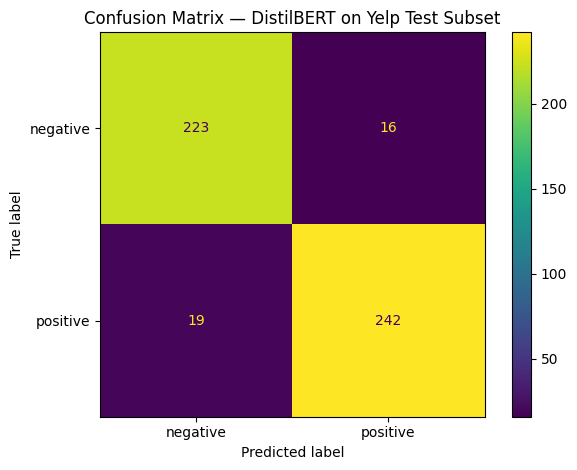

In [14]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
disp.plot(values_format="d")
plt.title("Confusion Matrix — DistilBERT on Yelp Test Subset")
plt.tight_layout()
plt.savefig("task4_confusion_matrix.png", dpi=150)
plt.show()

## 7. Misclassified examples

In [15]:
results_df = pd.DataFrame({
    "review": test_ds["text"],
    "true": y_true, "pred": y_pred,
    "confidence": probs.max(axis=1),
})
results_df["correct"] = results_df["true"] == results_df["pred"]

errors = results_df[~results_df["correct"]].sort_values("confidence", ascending=False)
for _, row in errors.head(2).iterrows():
    true_lbl = "positive" if row["true"] == 1 else "negative"
    pred_lbl = "positive" if row["pred"] == 1 else "negative"
    print(f"True: {true_lbl} | Predicted: {pred_lbl} (confidence {row['confidence']:.2f})")
    print(row["review"][:300], "...\n")

True: positive | Predicted: negative (confidence 0.99)
I have to say that the Wynn buffet did impress me.  The different assortment of higher quality food (for a buffet) was excellent.  However, I was conflicted with giving it 3 stars because of the service.  It took a long time for my girlfriend and I to get a glass of water.  Then afterwards, they for ...

True: positive | Predicted: negative (confidence 0.99)
Beautiful Art-Deco dinner theater with amazing talent.  A great excuse to get dressed up!\n\nBought tickets online for my hubby and my dad to see My Fair Lady when he was visiting from out of town.\n\nOnline ordering and the website is HORRIBLE.  Even the theater manager said it was best to call the ...



## 8. Comparison with the Task 2 classical baseline

| | Task 2 (TF-IDF + classical) | Task 4 (DistilBERT) |
|---|---|---|
| Accuracy | [INSERT from Task 2] | [INSERT: value above] |
| F1 | [INSERT] | [INSERT] |
| Training time | seconds | [INSERT: `training_minutes` above] minutes |
| Model size | a few MB (vectoriser + linear weights) | ~260MB (66M parameters) |
| Interpretability | Direct — inspect n-gram coefficients | Low — requires separate explainability tooling (e.g. attention/SHAP) |
| Resource needs | CPU, low memory | GPU recommended for practical training time |
| Handles negation/sarcasm | Poorly (see Task 2 error analysis) | Better, though not perfectly — check the misclassified examples above |

Fill in the bracketed cells with your own numbers once both notebooks have been run. In
general, expect the transformer to outperform the classical baseline on accuracy/F1 —
particularly on the negation and mixed-sentiment cases the classical model struggled with —
at the cost of training time, model size, and interpretability.

## 9. Practical implications

**Error patterns.** [INSERT: do the misclassified examples above skew toward the same
negation/sarcasm/mixed-sentiment patterns seen in Task 2, or does the transformer fail on
different cases?]

**Resource use and speed.** Fine-tuning took [INSERT] minutes on [INSERT: GPU/CPU]. Inference
on a single review is fast (well under a second on GPU), but is still far more compute per
prediction than the classical model's TF-IDF lookup + linear multiply, which matters at high
request volume or on CPU-only infrastructure.

**Memory.** DistilBERT has ~66M parameters (~260MB in fp32), versus a few MB for the TF-IDF
vectoriser and linear model — a real difference for deployment on constrained hardware.

**Reliability.** As with the classical model, prediction confidence does not guarantee
correctness — a wrong prediction can still carry high softmax confidence, so any deployment
should treat confidence scores as calibration hints, not certainties, and should not skip
human review purely because confidence looks high.

**Fairness.** The model is fine-tuned on whatever star-rating patterns exist in the training
sample; if certain writing styles or topics are systematically rated more harshly, the model
inherits that pattern. This mirrors the bias risk discussed in Task 5 and is not automatically
fixed by using a transformer instead of a classical model.

**Monitoring.** A deployed version would need ongoing tracking of prediction distribution
drift, confidence calibration, and periodic re-evaluation against fresh labelled samples,
since review language and topics shift over time in ways a static fine-tuned checkpoint
won't adapt to on its own.

## 10. Quick inference check

In [16]:
def predict_sentiment(text):
    trainer.model.eval()
    encoded = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH).to(DEVICE)
    with torch.no_grad():
        logits = trainer.model(**encoded).logits
        probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    pred = int(np.argmax(probs))
    return id2label[pred], float(probs[pred])

for text in [
    "The food was cold and the service was incredibly slow.",
    "Amazing experience, will definitely come back again!",
    "I expected very little, yet I ended up loving almost every dish.",
]:
    label, conf = predict_sentiment(text)
    print(f"{label} ({conf:.1%}) <- {text}")

negative (99.0%) <- The food was cold and the service was incredibly slow.
positive (99.2%) <- Amazing experience, will definitely come back again!
positive (96.8%) <- I expected very little, yet I ended up loving almost every dish.


Extracting embeddings for the test set...


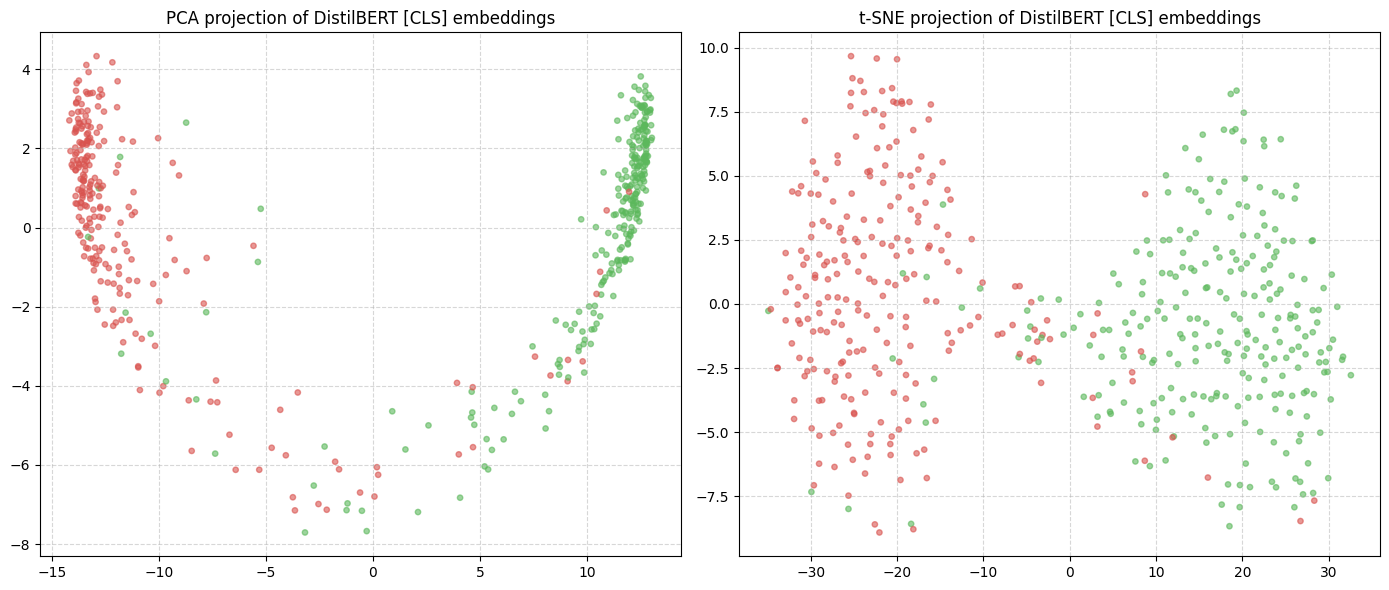

In [22]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch

# 1. Extract embeddings using our fine-tuned DistilBERT model
model.eval()
review_vectors = []

print("Extracting embeddings for the test set...")
for batch in tokenized_test:
    # Prepare inputs for the model
    inputs = {
        "input_ids": torch.tensor([batch["input_ids"]]).to(DEVICE),
        "attention_mask": torch.tensor([batch["attention_mask"]]).to(DEVICE)
    }
    with torch.no_grad():
        # Access the base DistilBERT transformer outputs
        outputs = model.distilbert(**inputs)
        # Use the [CLS] token representation (index 0) as the sentence embedding
        cls_embedding = outputs.last_hidden_state[0, 0].cpu().numpy()
        review_vectors.append(cls_embedding)

review_vectors = np.array(review_vectors)
review_sentiments = np.array(test_ds["label_bin"])

# 2. Project using PCA and t-SNE
VIZ_N = min(1500, len(review_vectors))
viz_vecs = review_vectors[:VIZ_N]
viz_labels = review_sentiments[:VIZ_N]

# Use SEED for reproducibility
pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(viz_vecs)
tsne_2d = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(viz_vecs)

# 3. Plot the projections
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, coords, title in [(axes[0], pca_2d, "PCA"), (axes[1], tsne_2d, "t-SNE")]:
    colors = np.where(viz_labels == 1, "#5cb85c", "#d9534f")
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=colors, alpha=0.6, s=15)
    ax.set_title(f"{title} projection of DistilBERT [CLS] embeddings")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("task4_embedding_projection.png", dpi=150)
plt.show()